# 09 — Integrated 1-LJ vs 2-LJ Mother Tracking and Kinematics

This notebook combines the analysis patterns of `02`, `05`, and `08` using the 12-channel reprocessed background sample.

Analysis flow:

1. validate the 18 merged background samples and 12 channels;
2. compare inclusive, Signal-like (`both_pass`), and Background-like (`both_fail`) LJ-entry yields;
3. study background-process and generator-mother composition;
4. compare 1-LJ and 2-LJ kinematics, including Signal-like/Background-like shapes.

### Overflow policy

- Every 1D kinematics yield and shape includes underflow and overflow. Underflow is folded into the first visible bin and overflow into the last visible bin; variances are folded identically.
- Mother-PDG underflow and overflow are included in `Others`, because their exact PDG category cannot be recovered outside the stored axis range.
- No event-count histogram exists in this output. Quantities derived from an LJ histogram are therefore labeled **LJ-entry yield**, not event yield.

In [1]:
import os
import sys
from collections import defaultdict
from pathlib import Path

import coffea.util
import hist
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Compatibility for NumPy-2-created coffea files in the current image.
if "numpy._core.numeric" not in sys.modules:
    sys.modules["numpy._core.numeric"] = np.core.numeric

sidm_path = str(Path.cwd()).split("/sidm")[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)

from sidm.tools import utilities

utilities.set_plot_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
%matplotlib inline

In [2]:
cwd = Path.cwd()
if cwd.name == "Mother_Tracking":
    study_dir = cwd
elif (cwd / "studies" / "Mother_Tracking").exists():
    study_dir = cwd / "studies" / "Mother_Tracking"
else:
    raise RuntimeError(f"Cannot locate studies/Mother_Tracking from {cwd}")

INPUT_DIR = study_dir / "LJKin_MotherTracking_12ch_reprocess_v2_bkg_full_merge_v2"

SAMPLES = [
    "TTJets",
    "QCD_Pt15To20", "QCD_Pt20To30", "QCD_Pt30To50", "QCD_Pt50To80",
    "QCD_Pt80To120", "QCD_Pt120To170", "QCD_Pt170To300",
    "QCD_Pt300To470", "QCD_Pt470To600", "QCD_Pt600To800",
    "QCD_Pt800To1000", "QCD_Pt1000",
    "DYJetsToLL_M10to50", "DYJetsToLL_M50", "WW", "WZ", "ZZ",
]

# Bottom-to-top order for stacked plots.
BACKGROUND_GROUPS = {
    "Diboson": ["WW", "WZ", "ZZ"],
    "TT": ["TTJets"],
    "DY": [sample for sample in SAMPLES if sample.startswith("DYJets")],
    "QCD": [sample for sample in SAMPLES if sample.startswith("QCD_")],
}
GROUP_COLORS = {
    "Diboson": "#009E73", "TT": "#0072B2",
    "DY": "#E69F00", "QCD": "#6F2DA8",
}

BASE_CHANNELS = {
    "1 mu-LJ": "data_control_region_1muLj",
    "1 egm-LJ": "data_control_region_1egmLj",
    "1 mu-LJ + 1 egm-LJ": "data_control_region_1muLj_1egmLj",
    "2 mu-LJ": "data_control_region_2muLj",
}
REGION_SUFFIX = {
    "Inclusive": "",
    "Signal-like": "_both_pass",
    "Background-like": "_both_fail",
}
CHANNEL_COLORS = {
    "1 mu-LJ": "#0072B2", "1 egm-LJ": "#E69F00",
    "1 mu-LJ + 1 egm-LJ": "#009E73", "2 mu-LJ": "#CC79A7",
}
REGION_STYLES = {
    "Inclusive": ("black", "-"),
    "Signal-like": ("red", "-"),
    "Background-like": ("blue", "--"),
}
ANCHOR_HISTOGRAM = {
    "1 mu-LJ": "mu_lj_pt",
    "1 egm-LJ": "egm_lj_pt",
    "1 mu-LJ + 1 egm-LJ": "mu_lj_pt",
    "2 mu-LJ": "mu_lj_pt",
}

assert INPUT_DIR.is_dir(), f"Missing input directory: {INPUT_DIR}"
missing_files = [sample for sample in SAMPLES if not (INPUT_DIR / f"{sample}.coffea").is_file()]
assert not missing_files, f"Missing coffea files: {missing_files}"
print(f"Input: {INPUT_DIR}")
print(f"Samples: {len(SAMPLES)}")

Input: /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/Mother_Tracking/LJKin_MotherTracking_12ch_reprocess_v2_bkg_full_merge_v2
Samples: 18


## Load and validate the 12-channel outputs

In [3]:
out = {}
validation_rows = []
expected_channels = {
    f"{base}{suffix}"
    for base in BASE_CHANNELS.values()
    for suffix in REGION_SUFFIX.values()
}
required_hists = {
    "mu_lj_pt", "mu_lj_eta", "mu_lj_phi", "mu_lj_mass_small", "mu_lj_iso",
    "mu_lj_dRSpread", "mu_lj_muonN", "mu_lj_pfMu_n", "mu_lj_dsaMu_n",
    "egm_lj_pt", "egm_lj_eta", "egm_lj_phi", "egm_lj_mass_small", "egm_lj_iso",
    "egm_lj_dRSpread", "egm_lj_electronN", "egm_lj_photonN",
    "fs_gen_mother_id", "fs_e_gen_mother_id", "fs_mu_gen_mother_id", "fs_pho_gen_mother_id",
}

for sample in SAMPLES:
    loaded = coffea.util.load(INPUT_DIR / f"{sample}.coffea")
    sample_out = loaded.get("out", loaded)[sample]
    out[sample] = sample_out
    hists = sample_out["hists"]
    missing_hists = sorted(required_hists - set(hists))
    channel_axis = hists["mu_lj_pt"].axes["channel"]
    available_channels = set(channel_axis)
    missing_channels = sorted(expected_channels - available_channels)
    metadata = sample_out.get("metadata", {})
    validation_rows.append({
        "sample": sample,
        "n_events_processed": metadata.get("n_evts", np.nan),
        "n_histograms": len(hists),
        "n_channels": len(channel_axis),
        "missing_histograms": ", ".join(missing_hists),
        "missing_channels": ", ".join(missing_channels),
        "status": "ok" if not missing_hists and not missing_channels else "incomplete",
    })

validation = pd.DataFrame(validation_rows).set_index("sample")
display(validation)
assert validation["status"].eq("ok").all(), "At least one sample is incomplete"

,n_events_processed,n_histograms,n_channels,missing_histograms,missing_channels,status
sample,,,,,,
TTJets,2396626,26,12,,,ok
QCD_Pt15To20,853,26,12,,,ok
QCD_Pt20To30,22954,26,12,,,ok
QCD_Pt30To50,107897,26,12,,,ok
QCD_Pt50To80,212290,26,12,,,ok
QCD_Pt80To120,641772,26,12,,,ok
QCD_Pt120To170,605553,26,12,,,ok
QCD_Pt170To300,3795715,26,12,,,ok
QCD_Pt300To470,6999747,26,12,,,ok


## Histogram helpers and overflow handling

The checks below make the overflow convention explicit and reusable. `folded_1d` is used for both yields and plotted shapes.

In [4]:
def channel_name(channel_label, region):
    return f"{BASE_CHANNELS[channel_label]}{REGION_SUFFIX[region]}"


def sum_histogram(samples, channel, histogram_name):
    total = None
    used = []
    for sample in samples:
        histogram = out[sample]["hists"][histogram_name][{"channel": channel}]
        total = histogram.copy() if total is None else total + histogram
        used.append(sample)
    if total is None:
        raise RuntimeError(f"No histogram found: {histogram_name}, {channel}")
    return total, used


def folded_1d(histogram):
    values = np.asarray(histogram.values(flow=True), dtype=float)
    variances = histogram.variances(flow=True)
    variances = np.abs(values) if variances is None else np.asarray(variances, dtype=float)
    folded_values = values[1:-1].copy()
    folded_variances = variances[1:-1].copy()
    folded_values[0] += values[0]
    folded_values[-1] += values[-1]
    folded_variances[0] += variances[0]
    folded_variances[-1] += variances[-1]
    return np.asarray(histogram.axes[0].edges), folded_values, folded_variances


def histogram_yield(histogram):
    _, values, variances = folded_1d(histogram)
    return float(values.sum()), float(variances.sum())


def normalized_shape(histogram, rebin=1):
    edges, values, variances = folded_1d(histogram)
    if rebin > 1:
        usable = (len(values) // rebin) * rebin
        values = values[:usable].reshape(-1, rebin).sum(axis=1)
        variances = variances[:usable].reshape(-1, rebin).sum(axis=1)
        edges = edges[:usable + 1:rebin]
        if len(edges) != len(values) + 1:
            edges = np.append(edges, histogram.axes[0].edges[usable])
    total = values.sum()
    if total <= 0:
        return edges, np.zeros_like(values), np.zeros_like(values)
    return edges, values / total, np.sqrt(variances) / total


def ratio_uncertainty(numerator, numerator_error, denominator, denominator_error):
    numerator = np.asarray(numerator, dtype=float)
    numerator_error = np.asarray(numerator_error, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    denominator_error = np.asarray(denominator_error, dtype=float)
    ratio = np.full(numerator.shape, np.nan)
    error = np.full(numerator.shape, np.nan)
    valid = np.isfinite(numerator) & np.isfinite(denominator) & (denominator > 0)
    ratio[valid] = numerator[valid] / denominator[valid]
    positive = valid & (numerator > 0)
    error[positive] = ratio[positive] * np.sqrt(
        (numerator_error[positive] / numerator[positive]) ** 2
        + (denominator_error[positive] / denominator[positive]) ** 2
    )
    zero = valid & (numerator == 0)
    error[zero] = numerator_error[zero] / denominator[zero]
    return ratio, error

## Inclusive, Signal-like, and Background-like LJ-entry yields

The anchor histogram is `mu_lj_pt` for mu-LJ channels and `egm_lj_pt` for the 1-egm-LJ channel. Since these histograms count LJ entries, this section deliberately does not label them as event yields.

In [5]:
channel_process_yields = {}
channel_process_errors = {}

for channel_label in BASE_CHANNELS:
    rows = []
    error_rows = []
    histogram_name = ANCHOR_HISTOGRAM[channel_label]
    for region in REGION_SUFFIX:
        row = {"region": region}
        error_row = {"region": region}
        channel = channel_name(channel_label, region)
        for group, samples in BACKGROUND_GROUPS.items():
            histogram, _ = sum_histogram(samples, channel, histogram_name)
            value, variance = histogram_yield(histogram)
            row[group] = value
            error_row[group] = np.sqrt(variance)
        rows.append(row)
        error_rows.append(error_row)
    channel_process_yields[channel_label] = pd.DataFrame(rows).set_index("region")
    channel_process_errors[channel_label] = pd.DataFrame(error_rows).set_index("region")
    display(Markdown(f"### {channel_label}: LJ-entry yield"))
    display(channel_process_yields[channel_label].round(5))

### 1 mu-LJ: LJ-entry yield

,Diboson,TT,DY,QCD
region,,,,
Inclusive,498.29570,18607.45381,77900.74685,9.590664e+06
Signal-like,12.43692,160.40908,2896.10225,1.464001e+05
Background-like,85.04686,12721.42250,3993.56787,6.505974e+06


### 1 egm-LJ: LJ-entry yield

,Diboson,TT,DY,QCD
region,,,,
Inclusive,37.30833,3057.59357,3935.61437,31405.84673
Signal-like,8.87781,163.68274,1612.24314,2079.21334
Background-like,10.54618,1299.64095,440.23890,14375.74011


### 1 mu-LJ + 1 egm-LJ: LJ-entry yield

,Diboson,TT,DY,QCD
region,,,,
Inclusive,19.57379,2831.71139,1025.45731,77947.64802
Signal-like,0.00000,3.27365,0.00000,228.75716
Background-like,1.41514,844.60293,25.98432,29968.61150


### 2 mu-LJ: LJ-entry yield

,Diboson,TT,DY,QCD
region,,,,
Inclusive,9.28604,491.04822,1037.56598,52238.59798
Signal-like,0.00000,6.54731,6.49608,0.02057
Background-like,0.82684,235.70314,0.00000,34321.31106


/tmp/ipykernel_5977/1653194889.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show(); plt.close(fig)


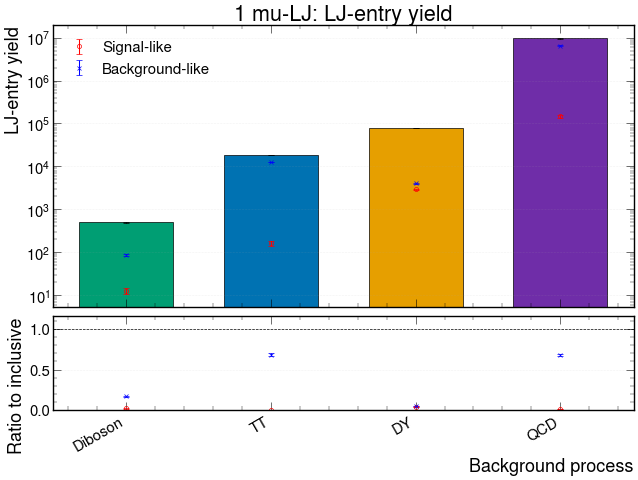

/tmp/ipykernel_5977/1653194889.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show(); plt.close(fig)


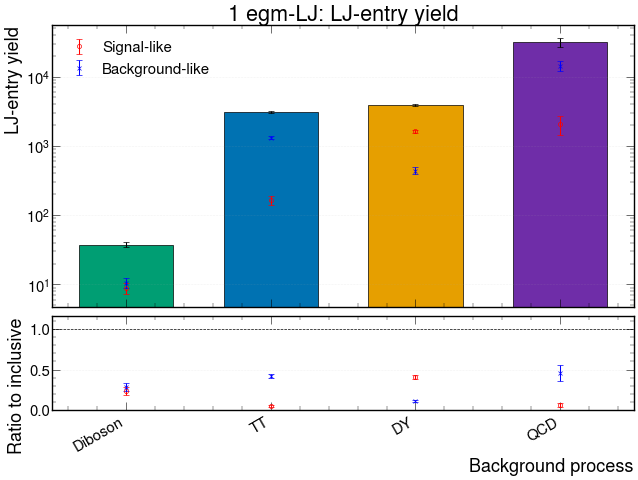

/tmp/ipykernel_5977/1653194889.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show(); plt.close(fig)


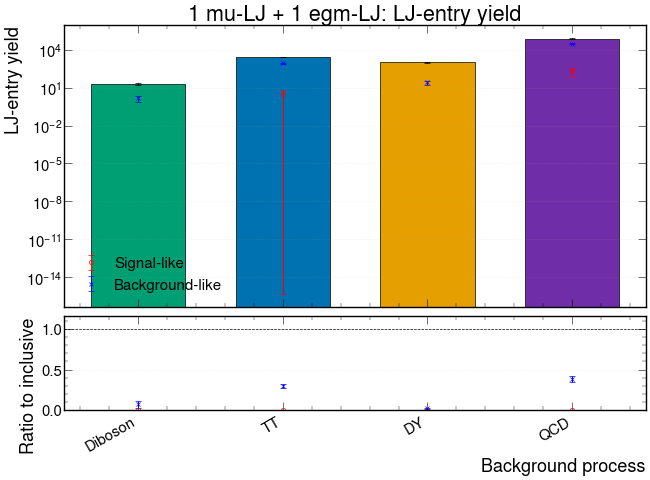

/tmp/ipykernel_5977/1653194889.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show(); plt.close(fig)


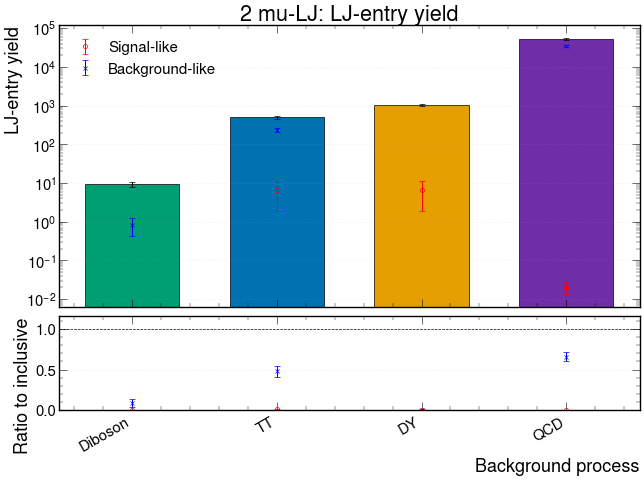

In [6]:
def plot_channel_yield_ratio(channel_label):
    table = channel_process_yields[channel_label]
    errors = channel_process_errors[channel_label]
    processes = list(BACKGROUND_GROUPS)
    x = np.arange(len(processes))
    inclusive = table.loc["Inclusive", processes].to_numpy(float)
    inclusive_error = errors.loc["Inclusive", processes].to_numpy(float)
    signal = table.loc["Signal-like", processes].to_numpy(float)
    signal_error = errors.loc["Signal-like", processes].to_numpy(float)
    background = table.loc["Background-like", processes].to_numpy(float)
    background_error = errors.loc["Background-like", processes].to_numpy(float)
    fig, (ax, rax) = plt.subplots(2, 1, figsize=(15, 10), sharex=True,
                                  gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})
    colors = [GROUP_COLORS[process] for process in processes]
    ax.bar(x, inclusive, color=colors, edgecolor="black", width=0.65)
    mask = inclusive > 0
    ax.errorbar(x[mask], inclusive[mask], yerr=inclusive_error[mask], fmt="none", ecolor="black", capsize=4)
    for values, errs, marker, color, label in (
        (signal, signal_error, "o", "red", "Signal-like"),
        (background, background_error, "x", "blue", "Background-like"),
    ):
        visible = values > 0
        ax.errorbar(x[visible], values[visible], yerr=errs[visible], marker=marker,
                    markerfacecolor="none" if marker == "o" else color,
                    color=color, ecolor=color, linestyle="none", capsize=4, label=label)
        ratio, ratio_error = ratio_uncertainty(values, errs, inclusive, inclusive_error)
        valid = np.isfinite(ratio)
        rax.errorbar(x[valid], ratio[valid], yerr=ratio_error[valid], marker=marker,
                     markerfacecolor="none" if marker == "o" else color,
                     color=color, ecolor=color, linestyle="none", capsize=4)
    ax.set_yscale("log")
    ax.set(title=f"{channel_label}: LJ-entry yield", ylabel="LJ-entry yield")
    ax.grid(axis="y", linestyle=":", alpha=0.3)
    ax.legend(frameon=False)
    rax.axhline(1, color="black", linestyle="--", linewidth=1)
    rax.set(ylabel="Ratio to inclusive", xlabel="Background process", ylim=(0, 1.15))
    rax.set_xticks(x, processes, rotation=30, ha="right")
    rax.grid(axis="y", linestyle=":", alpha=0.3)
    plt.tight_layout(); plt.show(); plt.close(fig)

for channel_label in BASE_CHANNELS:
    plot_channel_yield_ratio(channel_label)

## Background-process composition across the 12 channels

Only fractions are plotted here. Yield information is already contained in the Inclusive/Signal-like/Background-like panels above.

,Diboson,TT,DY,QCD
channel,,,,
1 mu-LJ — Inclusive,0.01,0.19,0.80,99.00
1 mu-LJ — Signal-like,0.01,0.11,1.94,97.95
1 mu-LJ — Background-like,0.00,0.20,0.06,99.74
1 egm-LJ — Inclusive,0.10,7.95,10.24,81.71
1 egm-LJ — Signal-like,0.23,4.24,41.72,53.81
1 egm-LJ — Background-like,0.07,8.06,2.73,89.15
1 mu-LJ + 1 egm-LJ — Inclusive,0.02,3.46,1.25,95.26
1 mu-LJ + 1 egm-LJ — Signal-like,0.00,1.41,0.00,98.59
1 mu-LJ + 1 egm-LJ — Background-like,0.00,2.74,0.08,97.17


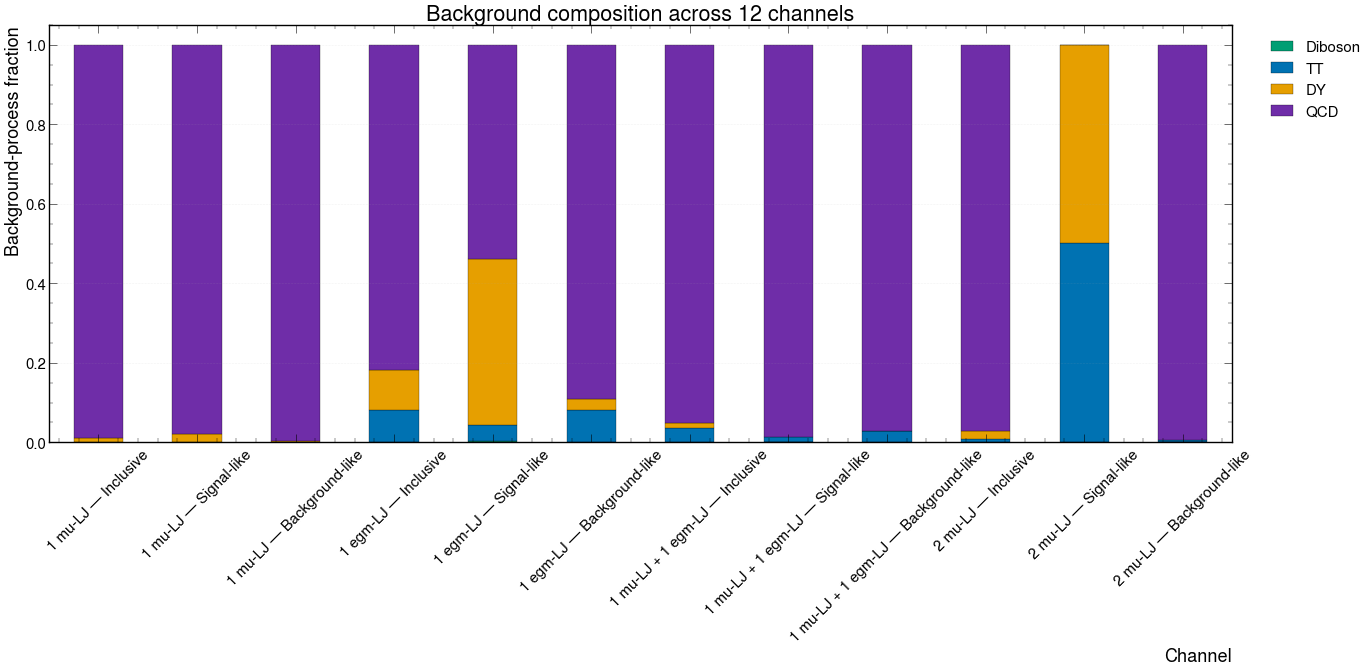

In [17]:
process_fraction_rows = []
for channel_label in BASE_CHANNELS:
    for region in REGION_SUFFIX:
        yields = channel_process_yields[channel_label].loc[region]
        total = yields.sum()
        row = {"channel": f"{channel_label} — {region}"}
        for process in BACKGROUND_GROUPS:
            row[process] = yields[process] / total if total > 0 else 0.0
        process_fraction_rows.append(row)
process_fraction_table = pd.DataFrame(process_fraction_rows).set_index("channel")
display((100 * process_fraction_table).round(2))
ax = process_fraction_table.plot(
    kind="bar", stacked=True, figsize=(28, 14),
    color=[GROUP_COLORS[p] for p in process_fraction_table.columns],
    edgecolor="black", linewidth=0.4,
)
ax.set(xlabel="Channel", ylabel="Background-process fraction", title="Background composition across 12 channels")
ax.tick_params(axis="x", rotation=45)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
ax.grid(axis="y", linestyle=":", alpha=0.3)
plt.tight_layout(); plt.show(); plt.close()

## Generator-mother composition

In [8]:
MOTHER_CATEGORY_ORDER = [
    "Z", "W", "e", r"$\pi$", r"$\eta$/$\omega$",
    "B Meson", "D Meson", "Quark/Gluon", r"J/$\Psi$", "Others",
]
MOTHER_COLORS = {
    "Z": "#0072B2", "W": "#E69F00", "e": "#CC79A7",
    r"$\pi$": "#009E73", r"$\eta$/$\omega$": "#56B4E9",
    "B Meson": "#D55E00", "D Meson": "#F0E442",
    "Quark/Gluon": "#6F2DA8", r"J/$\Psi$": "#8C564B", "Others": "#7F7F7F",
}
MOTHER_HISTOGRAMS = {
    "All matched objects": "fs_gen_mother_id",
    "Electron": "fs_e_gen_mother_id",
    "Muon": "fs_mu_gen_mother_id",
    "Photon": "fs_pho_gen_mother_id",
}

def categorize_background_mother(pdgid):
    abs_id = abs(int(pdgid))
    if abs_id == 23: return "Z"
    if abs_id == 24: return "W"
    if abs_id == 11: return "e"
    if abs_id in (111, 211): return r"$\pi$"
    if abs_id in (221, 223): return r"$\eta$/$\omega$"
    if abs_id in (511, 521, 531, 541): return "B Meson"
    if abs_id in (411, 421, 423, 431): return "D Meson"
    if abs_id in (1, 2, 3, 4, 5, 6, 9, 21): return "Quark/Gluon"
    if abs_id == 443: return r"J/$\Psi$"
    return "Others"


def categorize_mother_histogram(histogram):
    flow_values = np.asarray(histogram.values(flow=True), dtype=float)
    flow_variances = histogram.variances(flow=True)
    flow_variances = np.abs(flow_values) if flow_variances is None else np.asarray(flow_variances, dtype=float)
    centers = np.asarray(histogram.axes[0].centers, dtype=int)
    yields = defaultdict(float)
    variances = defaultdict(float)
    for pdgid, value, variance in zip(centers, flow_values[1:-1], flow_variances[1:-1]):
        category = categorize_background_mother(pdgid)
        yields[category] += float(value)
        variances[category] += float(variance)
    yields["Others"] += float(flow_values[0] + flow_values[-1])
    variances["Others"] += float(flow_variances[0] + flow_variances[-1])
    return yields, variances


def mother_category_table(samples, channel, histogram_name):
    histogram, _ = sum_histogram(samples, channel, histogram_name)
    yields, variances = categorize_mother_histogram(histogram)
    return (
        pd.Series(yields).reindex(MOTHER_CATEGORY_ORDER, fill_value=0.0),
        np.sqrt(pd.Series(variances).reindex(MOTHER_CATEGORY_ORDER, fill_value=0.0)),
    )

### Common mother order (lowest total yield first)

,mother-object yield
e,5.617491e+03
W,4.235182e+04
Z,6.204275e+04
$\eta$/$\omega$,2.669165e+06
Others,1.000486e+07
J/$\Psi$,1.042951e+07
Quark/Gluon,1.339168e+07
$\pi$,1.680646e+07
B Meson,2.387354e+07
D Meson,2.446452e+07


### All matched objects: mother composition (%)

,e,W,Z,$\eta$/$\omega$,Others,J/$\Psi$,Quark/Gluon,$\pi$,B Meson,D Meson
channel,,,,,,,,,,
1 mu-LJ — Inclusive,0.00,0.03,0.07,2.02,10.35,8.42,14.54,15.51,24.07,25.00
1 mu-LJ — Signal-like,0.00,0.02,0.39,1.97,11.65,5.16,30.61,13.59,18.23,18.37
1 mu-LJ — Background-like,0.00,0.02,0.00,2.23,10.10,8.18,10.41,16.28,25.95,26.82
1 egm-LJ — Inclusive,1.41,3.07,0.06,2.51,10.42,0.06,9.12,50.45,17.09,5.81
1 egm-LJ — Signal-like,0.56,1.60,0.06,2.63,24.36,0.00,18.63,49.03,2.52,0.61
1 egm-LJ — Background-like,0.82,2.07,0.00,3.16,8.75,0.11,5.25,41.52,28.97,9.34
1 mu-LJ + 1 egm-LJ — Inclusive,0.21,0.56,0.08,2.76,8.91,5.63,6.95,28.84,23.88,22.17
1 mu-LJ + 1 egm-LJ — Signal-like,0.00,0.32,0.00,0.00,15.39,23.34,14.22,32.80,8.40,5.52
1 mu-LJ + 1 egm-LJ — Background-like,0.13,0.33,0.01,2.27,7.22,6.35,5.97,26.86,27.52,23.35


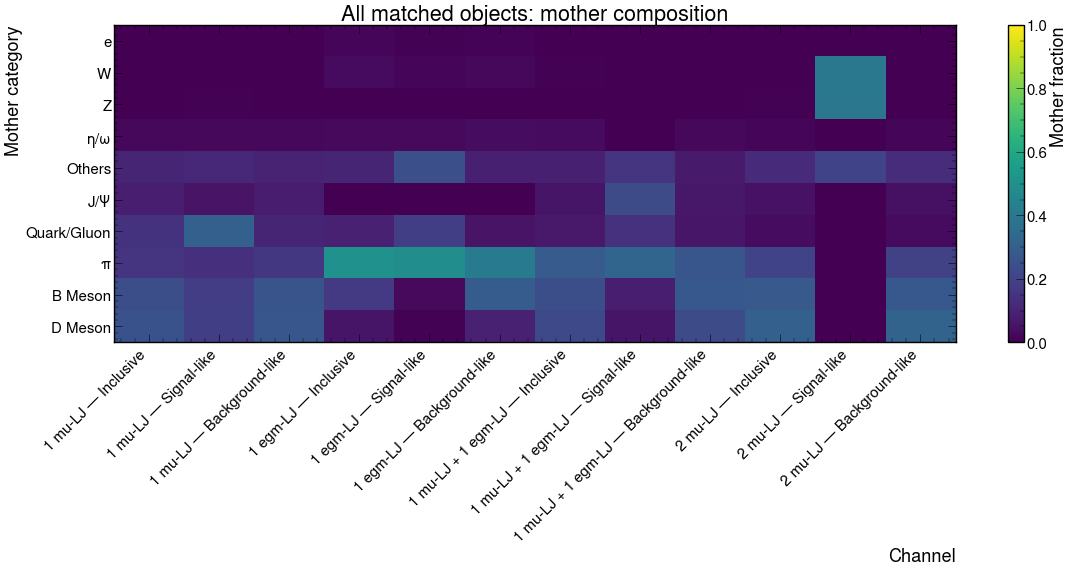

### Electron: mother composition (%)

,e,W,Z,$\eta$/$\omega$,Others,J/$\Psi$,Quark/Gluon,$\pi$,B Meson,D Meson
channel,,,,,,,,,,
1 mu-LJ — Inclusive,0.00,0.01,0.00,1.83,7.54,0.05,46.47,20.25,6.26,17.59
1 mu-LJ — Signal-like,0.00,0.00,0.00,0.57,8.24,0.00,64.72,12.98,4.73,8.75
1 mu-LJ — Background-like,0.00,0.00,0.00,1.37,7.10,0.05,45.28,21.09,6.50,18.60
1 egm-LJ — Inclusive,0.05,17.38,0.28,1.71,2.88,0.36,12.89,7.72,48.59,8.13
1 egm-LJ — Signal-like,0.00,52.38,0.17,0.00,5.87,0.00,29.33,0.06,0.00,12.19
1 egm-LJ — Background-like,0.03,8.12,0.02,2.01,2.42,0.46,12.56,9.09,57.03,8.25
1 mu-LJ + 1 egm-LJ — Inclusive,0.03,3.94,0.22,2.68,5.34,0.70,24.06,13.49,34.88,14.67
1 mu-LJ + 1 egm-LJ — Signal-like,0.00,0.00,0.00,0.00,0.00,0.00,99.29,0.03,0.65,0.02
1 mu-LJ + 1 egm-LJ — Background-like,0.00,1.71,0.05,0.80,5.29,0.28,24.82,9.49,40.88,16.68


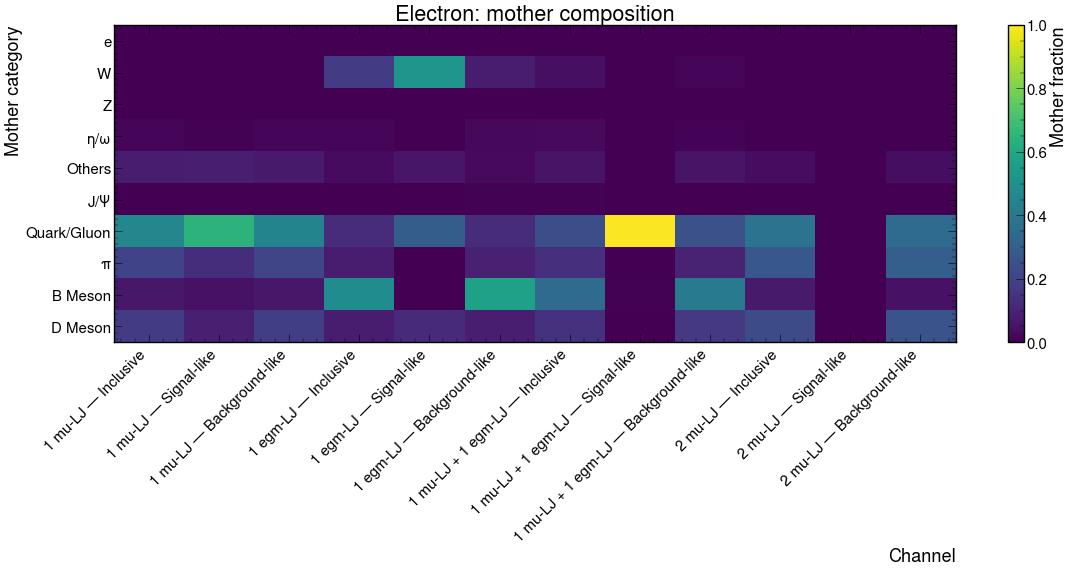

### Muon: mother composition (%)

,e,W,Z,$\eta$/$\omega$,Others,J/$\Psi$,Quark/Gluon,$\pi$,B Meson,D Meson
channel,,,,,,,,,,
1 mu-LJ — Inclusive,0.00,0.05,0.14,2.59,9.67,15.83,15.05,10.74,23.20,22.73
1 mu-LJ — Signal-like,0.00,0.04,0.72,2.56,9.99,9.38,31.30,12.32,16.98,16.72
1 mu-LJ — Background-like,0.00,0.03,0.01,2.93,9.71,15.78,9.72,11.27,25.58,24.98
1 egm-LJ — Inclusive,0.00,0.01,0.10,0.25,29.64,0.00,1.56,54.61,1.71,12.13
1 egm-LJ — Signal-like,0.00,0.00,2.13,0.00,12.98,0.00,0.07,33.86,46.25,4.71
1 egm-LJ — Background-like,0.00,0.00,0.00,0.43,36.98,0.00,0.45,42.94,0.70,18.50
1 mu-LJ + 1 egm-LJ — Inclusive,0.02,0.41,0.15,1.26,10.89,14.85,6.95,16.73,23.23,25.51
1 mu-LJ + 1 egm-LJ — Signal-like,0.00,0.74,0.00,0.00,28.76,53.88,0.36,1.88,8.84,5.53
1 mu-LJ + 1 egm-LJ — Background-like,0.00,0.23,0.00,1.91,8.17,18.16,4.15,16.94,23.92,26.52


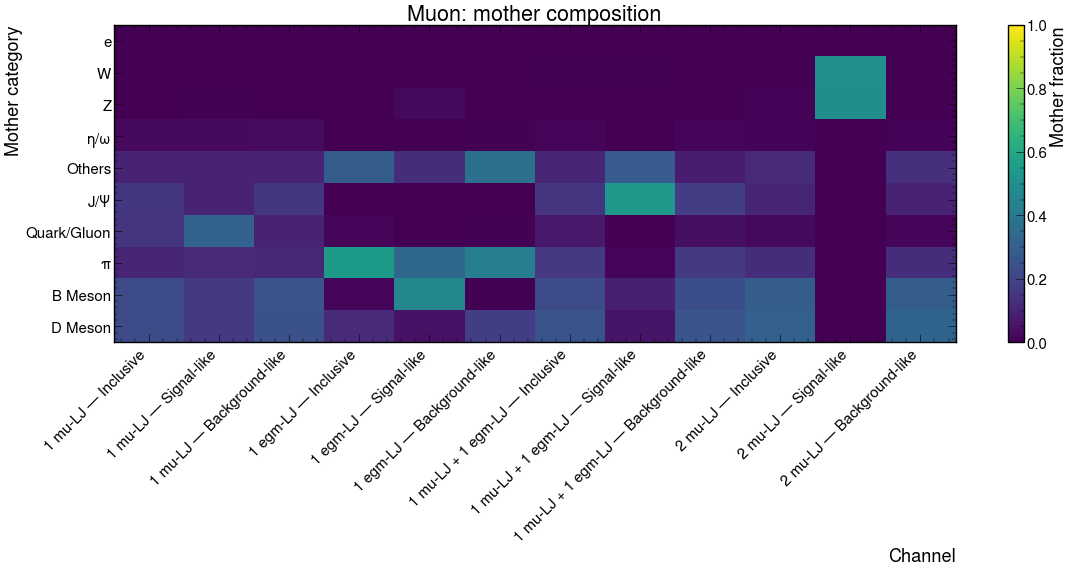

### Photon: mother composition (%)

,e,W,Z,$\eta$/$\omega$,Others,J/$\Psi$,Quark/Gluon,$\pi$,B Meson,D Meson
channel,,,,,,,,,,
1 mu-LJ — Inclusive,0.00,0.01,0.0,11.89,5.62,0.0,6.48,75.05,0.01,0.94
1 mu-LJ — Signal-like,0.00,0.02,0.0,15.31,11.69,0.0,7.02,65.48,0.00,0.48
1 mu-LJ — Background-like,0.00,0.01,0.0,12.46,3.79,0.0,2.75,79.93,0.00,1.05
1 egm-LJ — Inclusive,3.14,0.27,0.0,4.93,8.03,0.0,12.89,70.73,0.00,0.00
1 egm-LJ — Signal-like,0.81,0.69,0.0,3.82,33.68,0.0,26.20,34.80,0.00,0.00
1 egm-LJ — Background-like,2.68,0.09,0.0,8.63,0.78,0.0,0.31,87.50,0.00,0.00
1 mu-LJ + 1 egm-LJ — Inclusive,1.09,0.07,0.0,10.88,1.83,0.0,6.21,79.69,0.00,0.23
1 mu-LJ + 1 egm-LJ — Signal-like,0.00,0.00,0.0,0.02,0.05,0.0,69.13,30.80,0.00,0.00
1 mu-LJ + 1 egm-LJ — Background-like,0.84,0.03,0.0,9.60,1.29,0.0,1.36,86.52,0.00,0.36


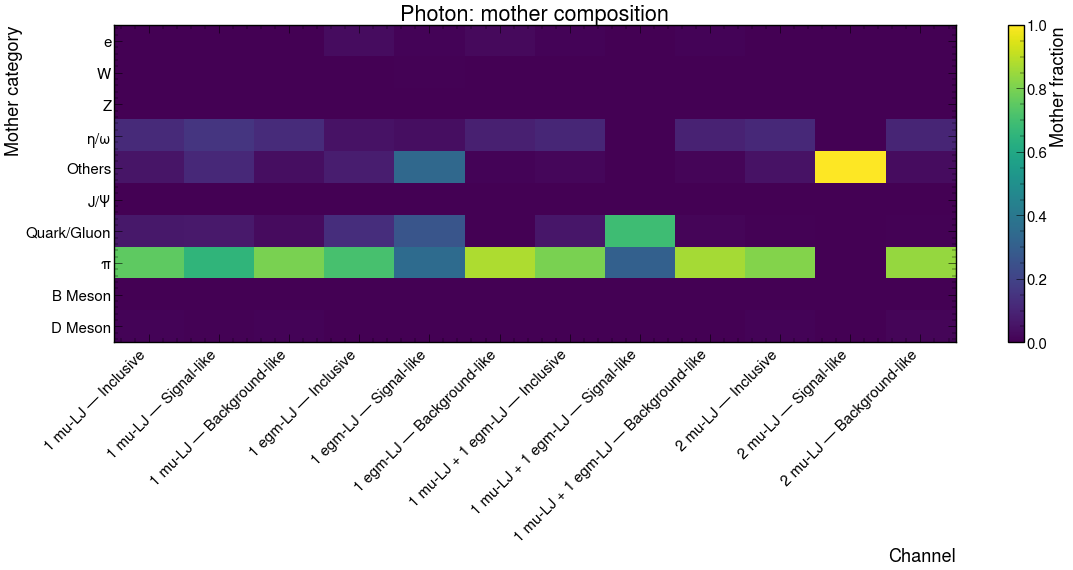

In [16]:
mother_fraction_tables = {}
global_mother_yield = pd.Series(0.0, index=MOTHER_CATEGORY_ORDER)
for object_label, histogram_name in MOTHER_HISTOGRAMS.items():
    rows = []
    for channel_label in BASE_CHANNELS:
        for region in REGION_SUFFIX:
            series, _ = mother_category_table(SAMPLES, channel_name(channel_label, region), histogram_name)
            total = series.sum()
            rows.append({"channel": f"{channel_label} — {region}", **(series / total if total > 0 else series * 0)})
            global_mother_yield = global_mother_yield.add(series, fill_value=0.0)
    mother_fraction_tables[object_label] = pd.DataFrame(rows).set_index("channel").reindex(columns=MOTHER_CATEGORY_ORDER)

MOTHER_STACK_ORDER = global_mother_yield.sort_values(kind="stable").index.tolist()
display(Markdown("### Common mother order (lowest total yield first)"))
display(global_mother_yield.reindex(MOTHER_STACK_ORDER).rename("mother-object yield").to_frame())

for object_label, table in mother_fraction_tables.items():
    table = table.reindex(columns=MOTHER_STACK_ORDER)
    mother_fraction_tables[object_label] = table
    display(Markdown(f"### {object_label}: mother composition (%)"))
    display((100 * table).round(2))
    fig, ax = plt.subplots(figsize=(24, 12))
    image = ax.imshow(table.T.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(np.arange(len(table.index)), table.index, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(table.columns)), table.columns)
    ax.set(title=f"{object_label}: mother composition", xlabel="Channel", ylabel="Mother category")
    fig.colorbar(image, ax=ax, label="Mother fraction")
    plt.tight_layout(); plt.show(); plt.close(fig)

## Process-resolved mother yield and Signal-like/Background-like ratios

Following notebook `02`, each panel compares Inclusive mother-object yield with Signal-like and Background-like values. The lower panel shows ratios to Inclusive with propagated uncertainties.

/tmp/ipykernel_5977/524050169.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show(); plt.close(fig)


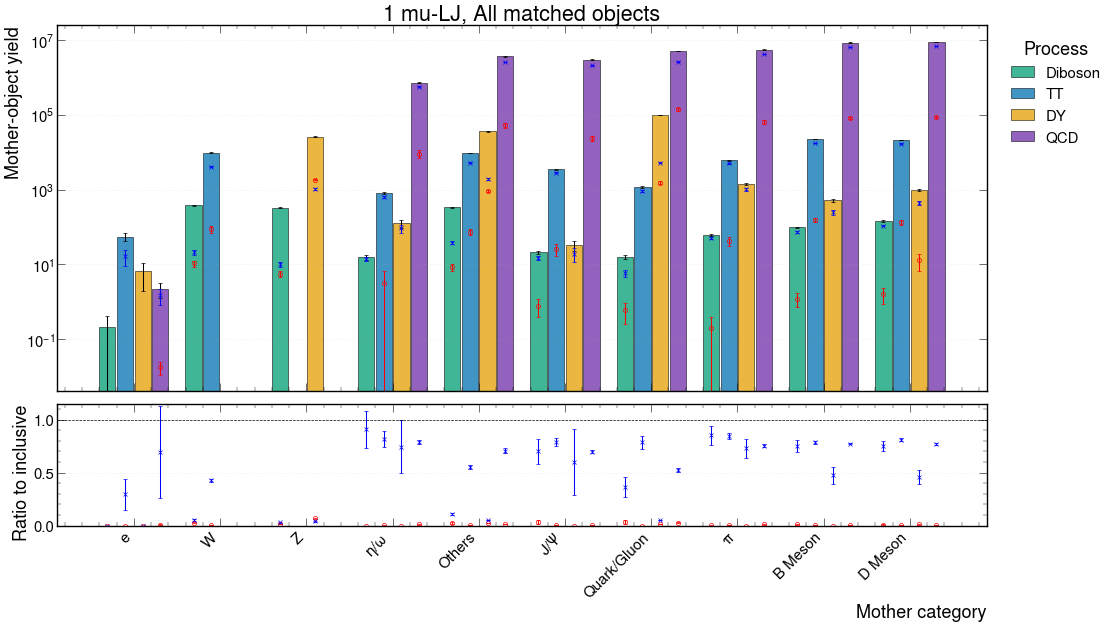

/tmp/ipykernel_5977/524050169.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show(); plt.close(fig)


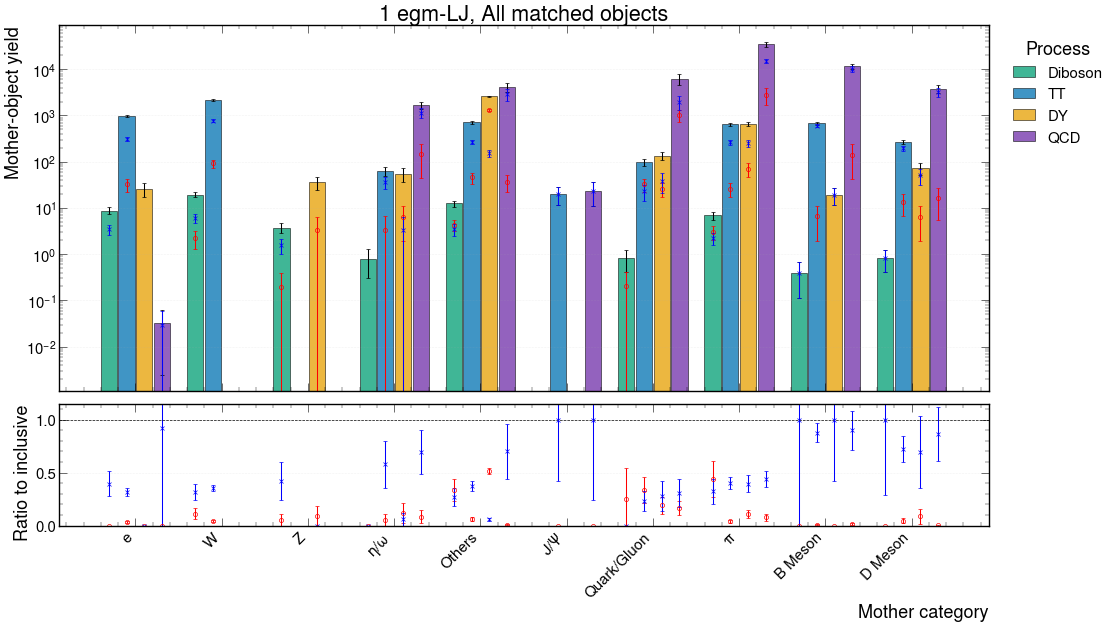

/tmp/ipykernel_5977/524050169.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show(); plt.close(fig)


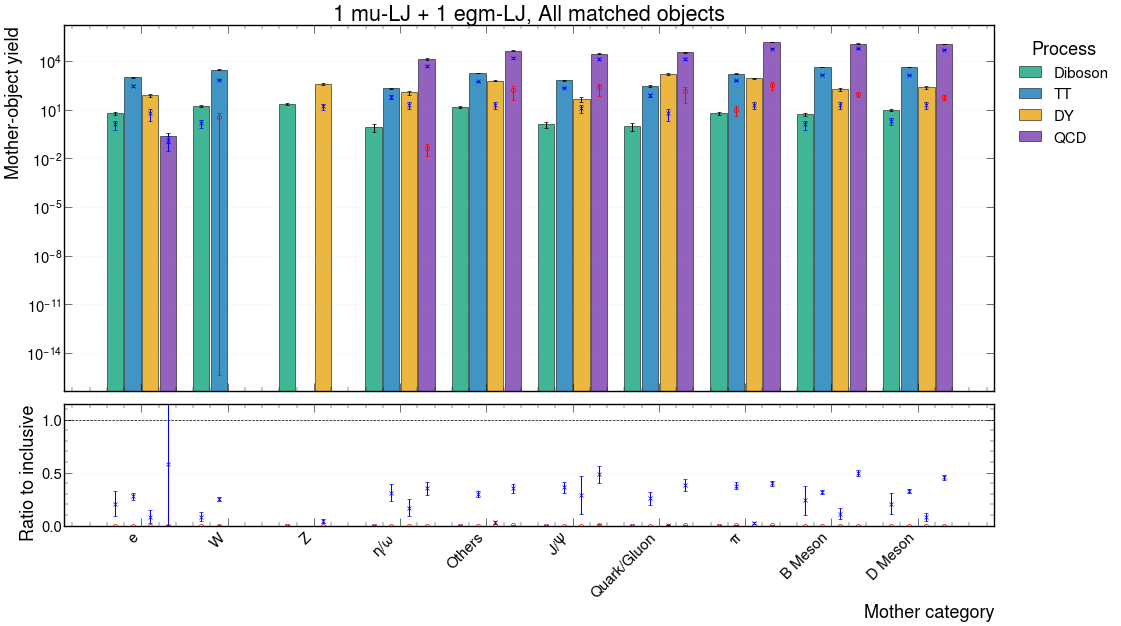

/tmp/ipykernel_5977/524050169.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show(); plt.close(fig)


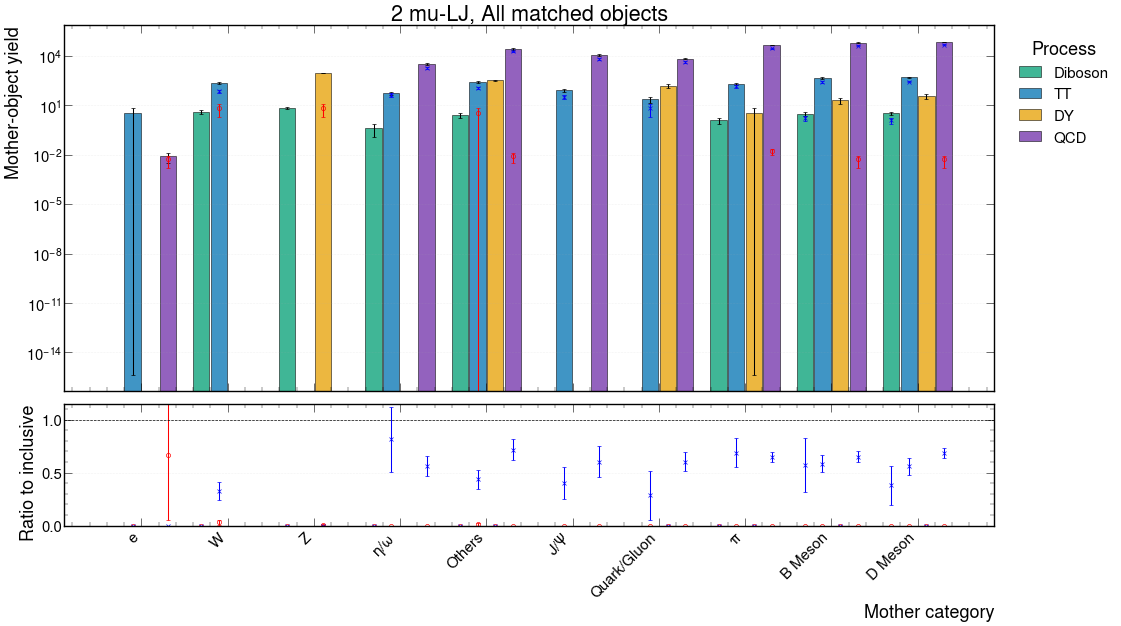

In [10]:
def process_mother_tables(channel_label, histogram_name):
    tables = {}
    errors = {}
    for region in REGION_SUFFIX:
        yield_rows = {}
        error_rows = {}
        for group, samples in BACKGROUND_GROUPS.items():
            series, error = mother_category_table(samples, channel_name(channel_label, region), histogram_name)
            yield_rows[group] = series
            error_rows[group] = error
        tables[region] = pd.DataFrame(yield_rows).T.reindex(columns=MOTHER_STACK_ORDER)
        errors[region] = pd.DataFrame(error_rows).T.reindex(columns=MOTHER_STACK_ORDER)
    return tables, errors


def plot_process_mother_overlay(channel_label, object_label, histogram_name):
    tables, errors = process_mother_tables(channel_label, histogram_name)
    processes = list(BACKGROUND_GROUPS)
    categories = MOTHER_STACK_ORDER
    x = np.arange(len(categories))
    width = 0.82 / len(processes)
    offsets = (np.arange(len(processes)) - (len(processes)-1)/2) * width
    fig, (ax, rax) = plt.subplots(2, 1, figsize=(24, 13), sharex=True,
                                  gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})
    for index, process in enumerate(processes):
        positions = x + offsets[index]
        inc = tables["Inclusive"].loc[process].to_numpy(float)
        inc_err = errors["Inclusive"].loc[process].to_numpy(float)
        ax.bar(positions, inc, width=0.92*width, color=GROUP_COLORS[process], edgecolor="black", alpha=0.75, label=process)
        mask = inc > 0
        ax.errorbar(positions[mask], inc[mask], yerr=inc_err[mask], fmt="none", ecolor="black", capsize=3)
        for region, marker, color in (("Signal-like", "o", "red"), ("Background-like", "x", "blue")):
            vals = tables[region].loc[process].to_numpy(float)
            errs = errors[region].loc[process].to_numpy(float)
            visible = vals > 0
            ax.errorbar(positions[visible], vals[visible], yerr=errs[visible], marker=marker,
                        markerfacecolor="none" if marker == "o" else color,
                        color=color, ecolor=color, linestyle="none", capsize=3)
            ratio, ratio_error = ratio_uncertainty(vals, errs, inc, inc_err)
            valid = np.isfinite(ratio)
            rax.errorbar(positions[valid], ratio[valid], yerr=ratio_error[valid], marker=marker,
                         markerfacecolor="none" if marker == "o" else color,
                         color=color, ecolor=color, linestyle="none", capsize=3)
    ax.set_yscale("log")
    ax.set(title=f"{channel_label}, {object_label}", ylabel="Mother-object yield")
    ax.grid(axis="y", linestyle=":", alpha=0.3)
    ax.legend(title="Process", bbox_to_anchor=(1.01, 1), loc="upper left")
    rax.axhline(1, color="black", linestyle="--", linewidth=1)
    rax.set(ylabel="Ratio to inclusive", xlabel="Mother category", ylim=(0, 1.15))
    rax.set_xticks(x, categories, rotation=45, ha="right")
    rax.grid(axis="y", linestyle=":", alpha=0.3)
    plt.tight_layout(); plt.show(); plt.close(fig)
    return tables, errors

mother_overlay_tables = {}
# The inclusive matched-object mother histogram is plotted by default.
for channel_label in BASE_CHANNELS:
    mother_overlay_tables[channel_label] = plot_process_mother_overlay(
        channel_label, "All matched objects", "fs_gen_mother_id"
    )

## 1-LJ vs 2-LJ kinematics

All-background normalized shapes compare the compatible 1-LJ and 2-LJ topologies. Error bars include histogram variances. Underflow and overflow are folded into the visible edge bins before normalization.

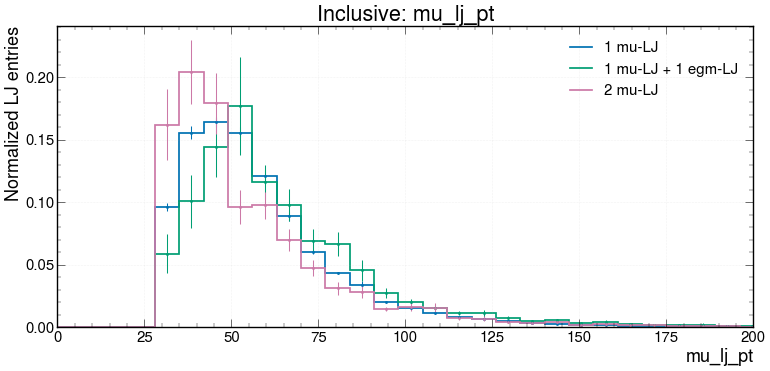

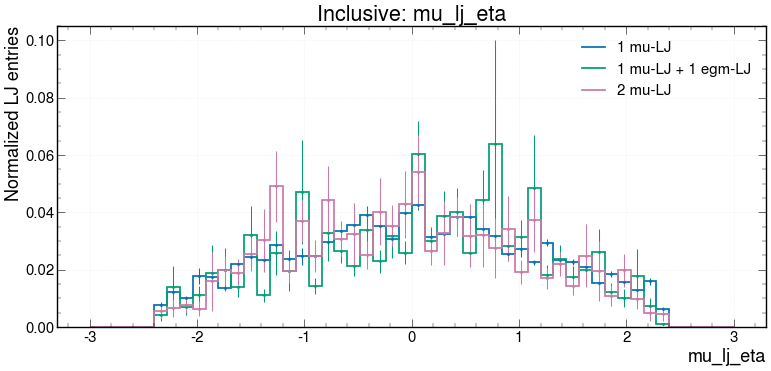

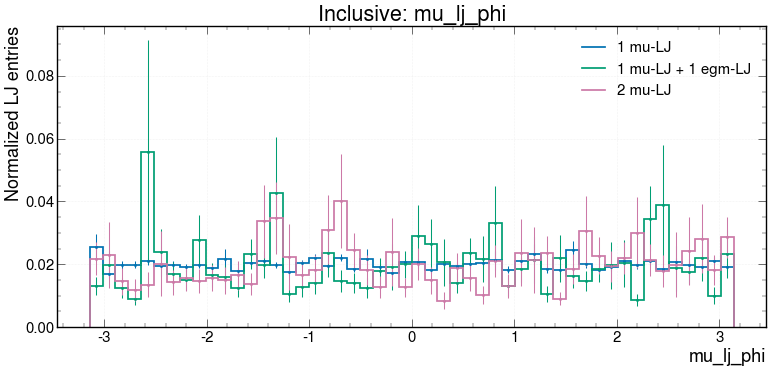

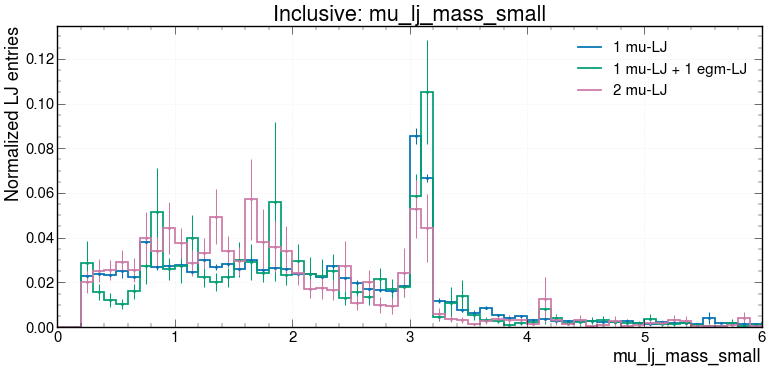

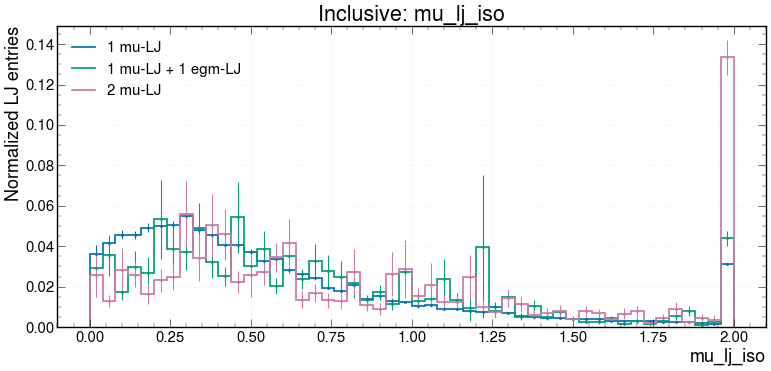

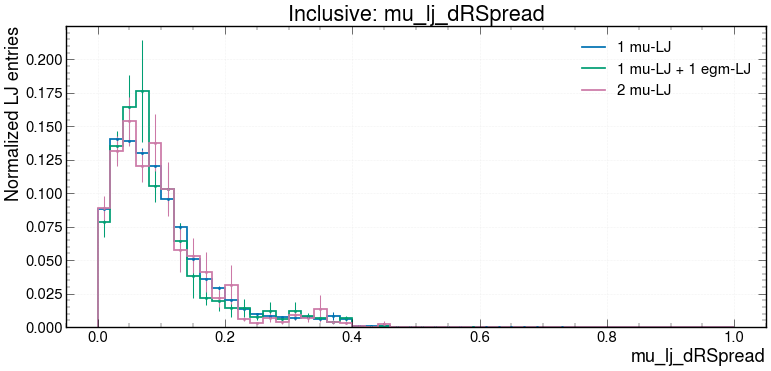

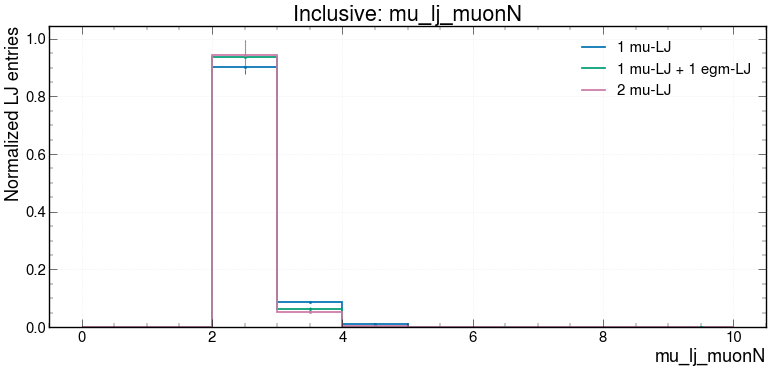

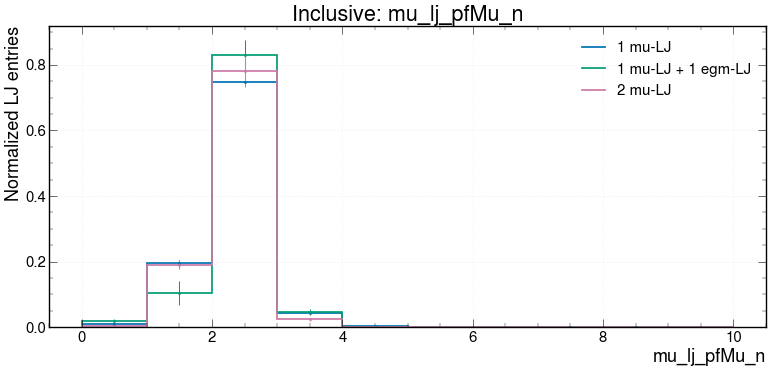

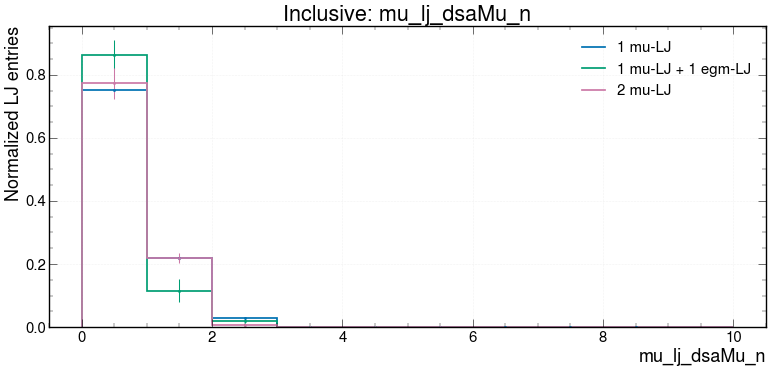

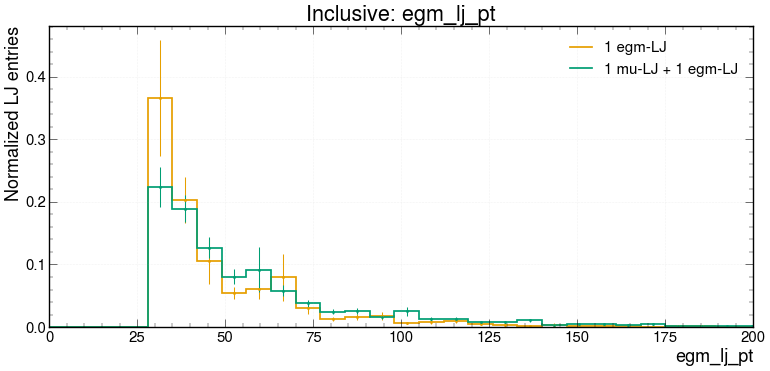

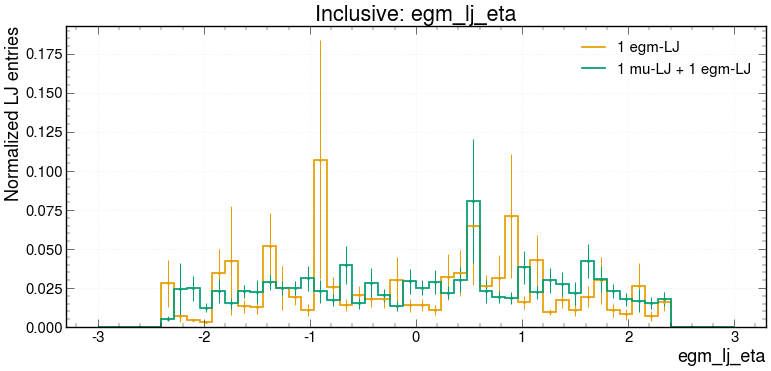

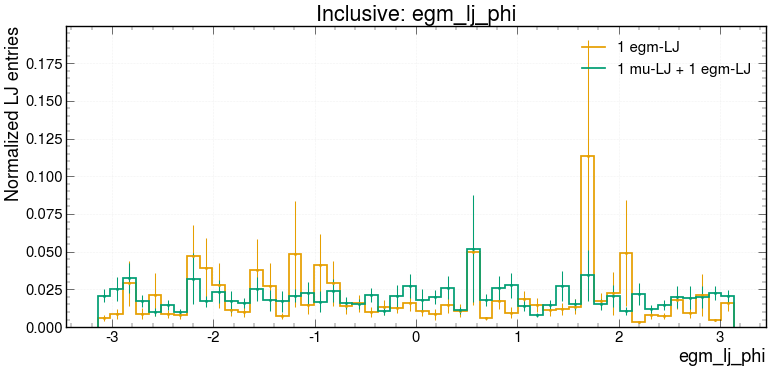

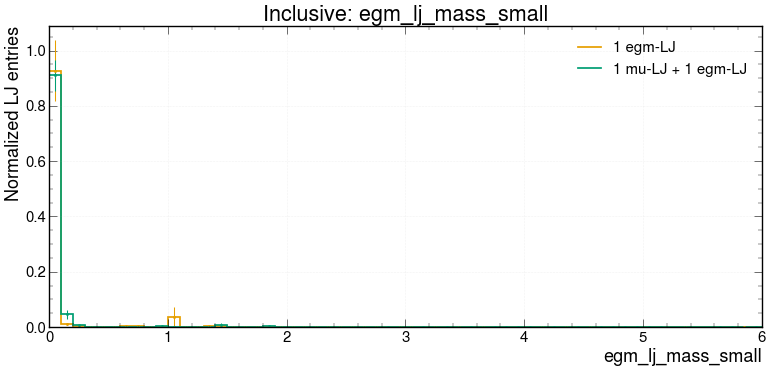

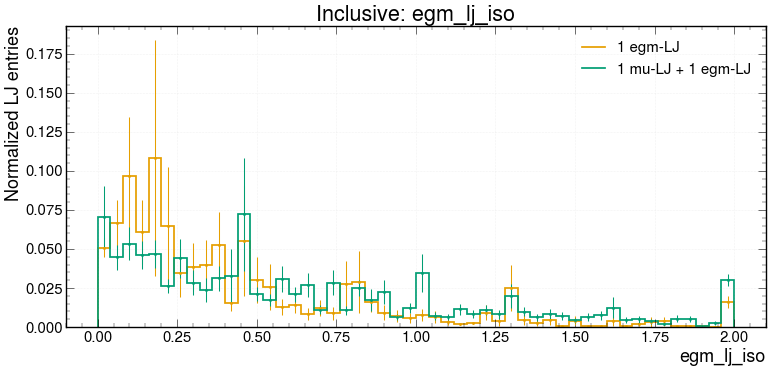

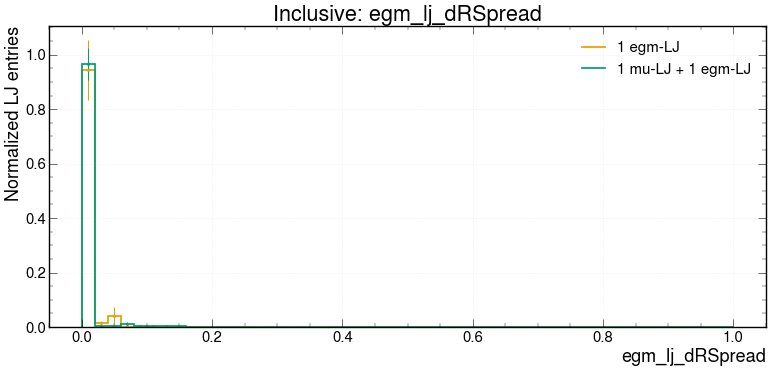

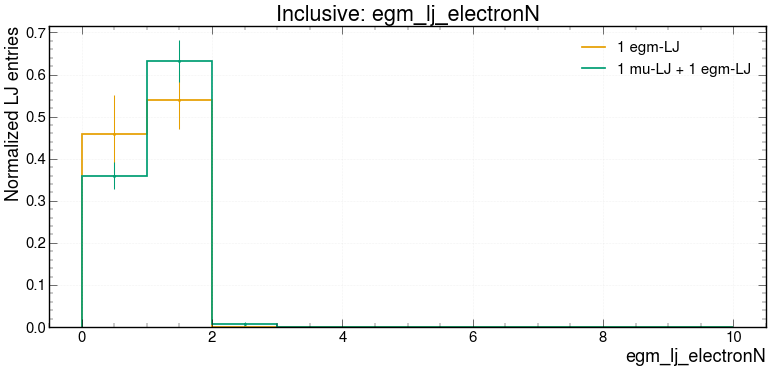

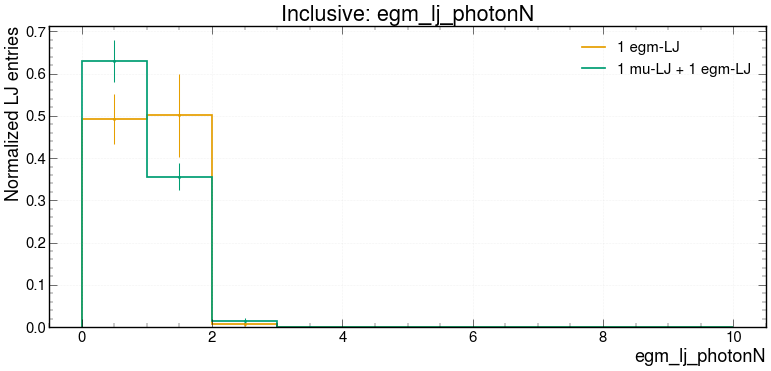

In [11]:
MU_VARIABLES = [
    "mu_lj_pt", "mu_lj_eta", "mu_lj_phi", "mu_lj_mass_small", "mu_lj_iso",
    "mu_lj_dRSpread", "mu_lj_muonN", "mu_lj_pfMu_n", "mu_lj_dsaMu_n",
]
EGM_VARIABLES = [
    "egm_lj_pt", "egm_lj_eta", "egm_lj_phi", "egm_lj_mass_small", "egm_lj_iso",
    "egm_lj_dRSpread", "egm_lj_electronN", "egm_lj_photonN",
]
VARIABLE_CHANNELS = {
    **{variable: ["1 mu-LJ", "1 mu-LJ + 1 egm-LJ", "2 mu-LJ"] for variable in MU_VARIABLES},
    **{variable: ["1 egm-LJ", "1 mu-LJ + 1 egm-LJ"] for variable in EGM_VARIABLES},
}
PLOT_OPTIONS = {
    "mu_lj_pt": {"xlim": (0, 200)}, "egm_lj_pt": {"xlim": (0, 200)},
    "mu_lj_mass_small": {"xlim": (0, 6)}, "egm_lj_mass_small": {"xlim": (0, 6)},
    "mu_lj_dRSpread": {"rebin": 5}, "egm_lj_dRSpread": {"rebin": 5},
}

def finish_shape_axis(ax, xlabel, title, xlim=None):
    ax.set(xlabel=xlabel, ylabel="Normalized LJ entries", title=title)
    if xlim is not None: ax.set_xlim(*xlim)
    ax.grid(linestyle=":", alpha=0.3)
    ax.legend(frameon=False)


def plot_channel_shapes(variable, region="Inclusive", rebin=1, xlim=None):
    fig, ax = plt.subplots(figsize=(16, 8))
    for channel_label in VARIABLE_CHANNELS[variable]:
        histogram, _ = sum_histogram(SAMPLES, channel_name(channel_label, region), variable)
        edges, shape, error = normalized_shape(histogram, rebin=rebin)
        color = CHANNEL_COLORS[channel_label]
        ax.stairs(shape, edges, label=channel_label, color=color, linewidth=2.5)
        centers = 0.5 * (edges[:-1] + edges[1:])
        visible = shape > 0
        ax.errorbar(centers[visible], shape[visible], yerr=error[visible], fmt="o", color=color, markersize=3)
    finish_shape_axis(ax, variable, f"{region}: {variable}", xlim=xlim)
    plt.tight_layout(); plt.show(); plt.close(fig)

for variable in MU_VARIABLES + EGM_VARIABLES:
    plot_channel_shapes(variable, **PLOT_OPTIONS.get(variable, {}))

## Signal-like vs Background-like kinematics

For each compatible channel, compare normalized shapes after the two selections. These plots emphasize shape changes rather than normalization, which is already shown in the yield-ratio section.

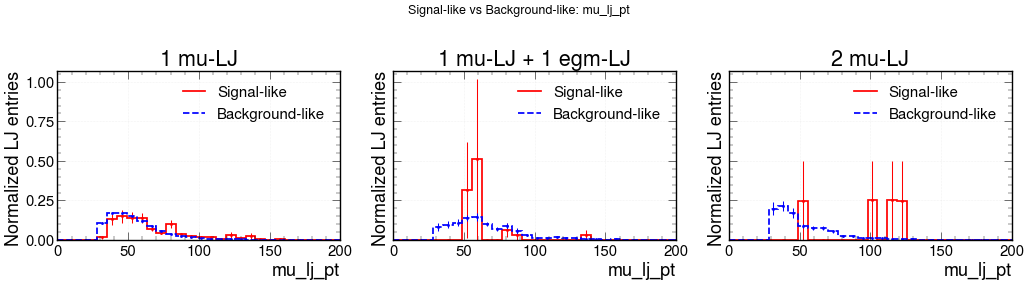

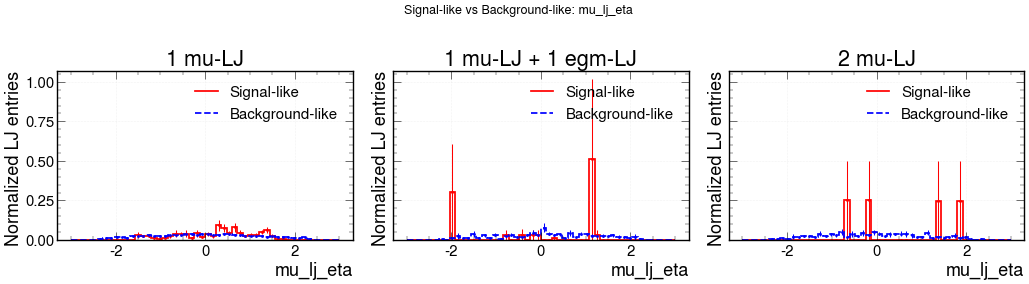

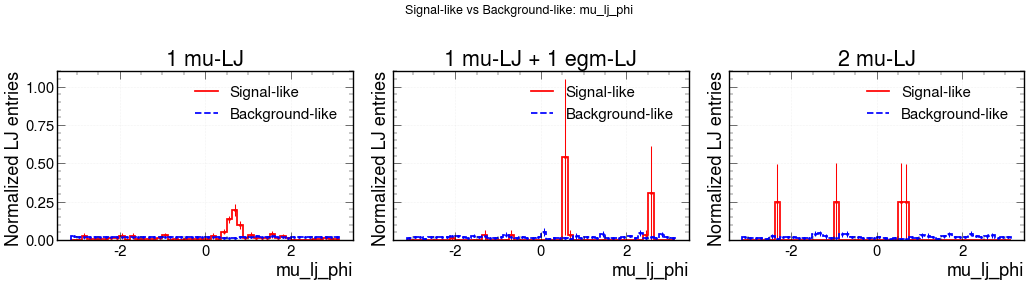

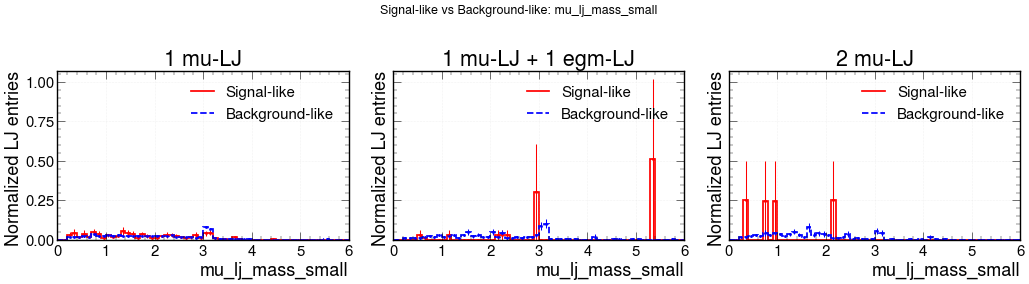

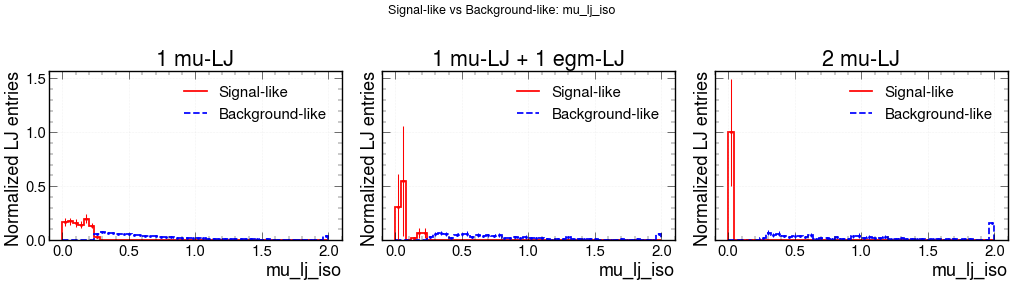

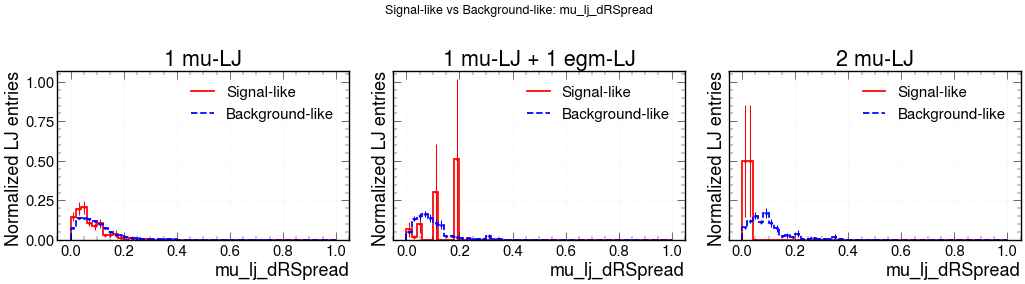

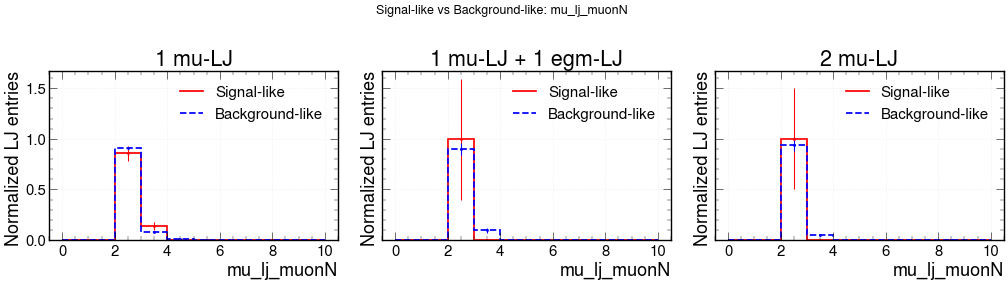

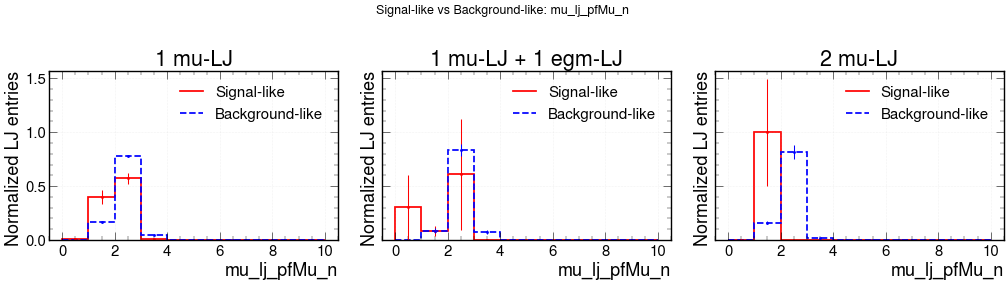

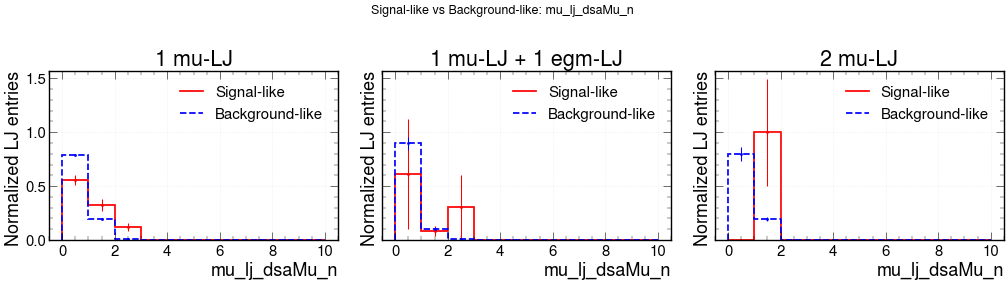

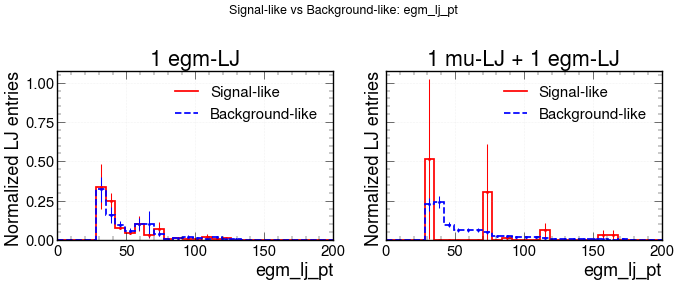

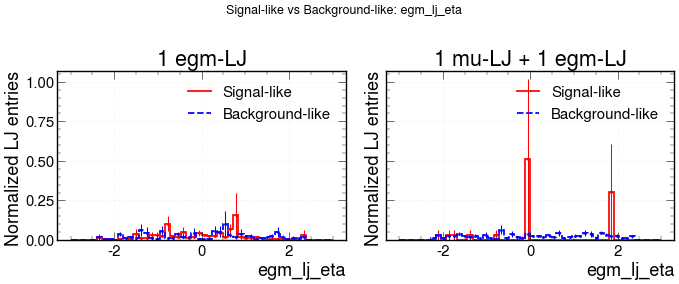

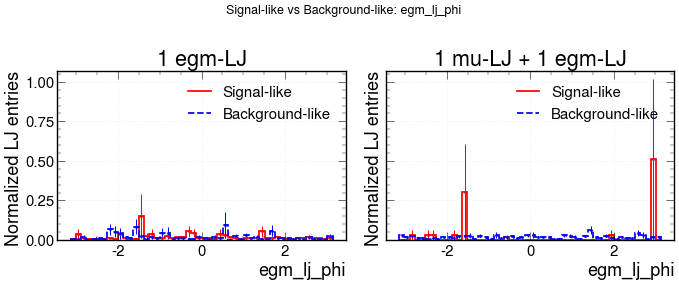

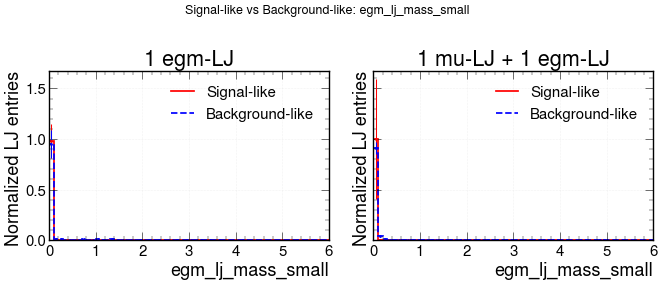

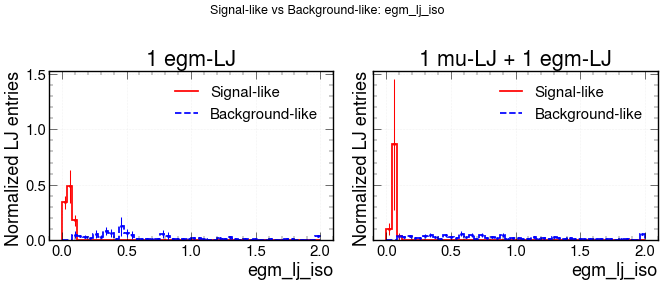

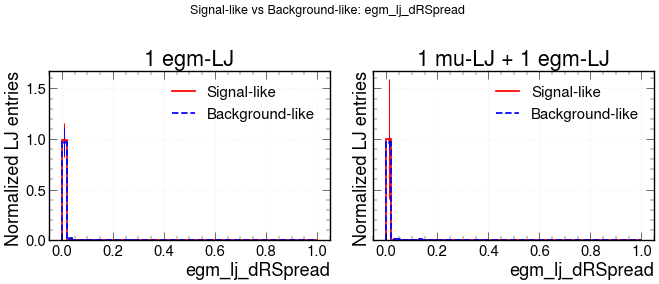

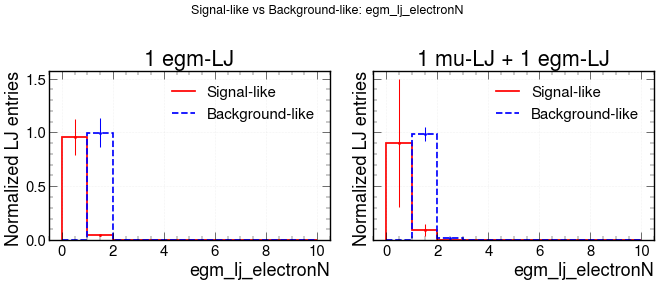

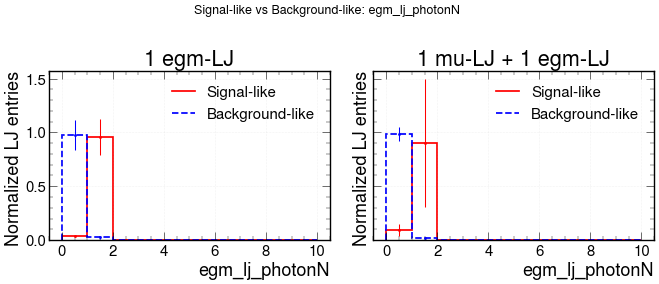

In [12]:
def plot_region_shapes(variable, rebin=1, xlim=None):
    channels = VARIABLE_CHANNELS[variable]
    fig, axes = plt.subplots(1, len(channels), figsize=(7*len(channels), 6), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, channel_label in zip(axes, channels):
        for region in ("Signal-like", "Background-like"):
            histogram, _ = sum_histogram(SAMPLES, channel_name(channel_label, region), variable)
            edges, shape, error = normalized_shape(histogram, rebin=rebin)
            color, linestyle = REGION_STYLES[region]
            ax.stairs(shape, edges, label=region, color=color, linestyle=linestyle, linewidth=2.5)
            centers = 0.5 * (edges[:-1] + edges[1:])
            visible = shape > 0
            ax.errorbar(centers[visible], shape[visible], yerr=error[visible], fmt="o", color=color, markersize=3)
        finish_shape_axis(ax, variable, channel_label, xlim=xlim)
    fig.suptitle(f"Signal-like vs Background-like: {variable}", fontsize=18)
    plt.tight_layout(); plt.show(); plt.close(fig)

for variable in MU_VARIABLES + EGM_VARIABLES:
    plot_region_shapes(variable, **PLOT_OPTIONS.get(variable, {}))

## Optional process-separated kinematics

Set `RUN_PROCESS_SEPARATED_KINEMATICS = True` to produce the same inclusive channel comparison for each background group. It is disabled by default to keep routine notebook execution compact.

In [13]:
RUN_PROCESS_SEPARATED_KINEMATICS = False

if RUN_PROCESS_SEPARATED_KINEMATICS:
    for group, samples in BACKGROUND_GROUPS.items():
        for variable in MU_VARIABLES + EGM_VARIABLES:
            options = PLOT_OPTIONS.get(variable, {})
            fig, ax = plt.subplots(figsize=(16, 8))
            for channel_label in VARIABLE_CHANNELS[variable]:
                histogram, _ = sum_histogram(samples, channel_name(channel_label, "Inclusive"), variable)
                edges, shape, error = normalized_shape(histogram, rebin=options.get("rebin", 1))
                color = CHANNEL_COLORS[channel_label]
                ax.stairs(shape, edges, label=channel_label, color=color, linewidth=2.5)
                centers = 0.5 * (edges[:-1] + edges[1:])
                visible = shape > 0
                ax.errorbar(centers[visible], shape[visible], yerr=error[visible], fmt="o", color=color, markersize=3)
            finish_shape_axis(ax, variable, f"{group}: Inclusive {variable}", xlim=options.get("xlim"))
            plt.tight_layout(); plt.show(); plt.close(fig)

## Compact summary

The tables below collect the main yield ratios for downstream comparison.

In [14]:
summary_rows = []
for channel_label in BASE_CHANNELS:
    yields = channel_process_yields[channel_label]
    for process in BACKGROUND_GROUPS:
        inclusive = yields.loc["Inclusive", process]
        summary_rows.append({
            "channel": channel_label,
            "process": process,
            "inclusive_lj_entry_yield": inclusive,
            "signal_like_fraction": yields.loc["Signal-like", process] / inclusive if inclusive > 0 else np.nan,
            "background_like_fraction": yields.loc["Background-like", process] / inclusive if inclusive > 0 else np.nan,
        })
lj_yield_summary = pd.DataFrame(summary_rows).set_index(["channel", "process"])
display(lj_yield_summary.round(5))

inclusive_lj_entry_yield  signal_like_fraction  \
channel            process                                                   
1 mu-LJ            Diboson              4.982957e+02               0.02496   
                   TT                   1.860745e+04               0.00862   
                   DY                   7.790075e+04               0.03718   
                   QCD                  9.590664e+06               0.01526   
1 egm-LJ           Diboson              3.730833e+01               0.23796   
                   TT                   3.057594e+03               0.05353   
                   DY                   3.935614e+03               0.40965   
                   QCD                  3.140585e+04               0.06620   
1 mu-LJ + 1 egm-LJ Diboson              1.957379e+01               0.00000   
                   TT                   2.831711e+03               0.00116   
                   DY                   1.025457e+03               0.00000   
                   QCD                  7.794765e+04               0.00293   
2 mu-LJ            Diboson              9.286040e+00               0.00000   
                   TT                   4.910482e+02               0.01333   
                   DY                   1.037566e+03               0.00626   
                   QCD                  5.223860e+04               0.00000   

                            background_like_fraction  
channel            process                            
1 mu-LJ            Diboson                   0.17068  
                   TT                        0.68367  
                   DY                        0.05126  
                   QCD                       0.67837  
1 egm-LJ           Diboson                   0.28268  
                   TT                        0.42505  
                   DY                        0.11186  
                   QCD                       0.45774  
1 mu-LJ + 1 egm-LJ Diboson                   0.07230  
                   TT                        0.29827  
                   DY                        0.02534  
                   QCD                       0.38447  
2 mu-LJ            Diboson                   0.08904  
                   TT                        0.48000  
                   DY                        0.00000  
                   QCD                       0.65701